# 케인즈의 교차선(Keynesian Cross) 모형
단기 국민소득 결정 

파이썬의 기본 모듈

In [1]:
# %% [markdown]
# ## 

import numpy as np
import matplotlib.pyplot as plt


Planned Expenditure

$$ PE = C + I + G  $$


$ C = c_0 + c_1 (Y-T) $  

$ I = I_0 $

$ G = G_0 $

$ T = T_0 $ 

In [5]:

# 1. 기초 고정 파라미터 설정
c0 = 100       # 기초소비 (소득이 0일 때의 소비)
I = 150        # 계획된 투자
T = 100        # 세금

# X축: 국민소득 (Y)의 범위 설정
Y_vals = np.linspace(0, 1500, 1000)


45도 선 : $ PE = Y $, 참조선, 기울기 1

PE 커브 : $ PE = c_0 + c_1 (Y-T_0) + I_0 + G_0 $. 45도 선보다 작은 기울기, $ c_1 $. 

In [3]:

# 2. 실시간 업데이트 및 시각화 함수
def simulate_keynesian_cross(c1=0.75, G=150):
    """
    c1: 한계소비성향 (Marginal Propensity to Consume, MPC)
    G: 정부지출 (정부의 재정정책 변수)
    """
    # 45도선 (AE = Y)
    AE_45 = Y_vals
    
    # 계획된 총지출 곡선 (AE = c0 + c1*(Y - T) + I + G)
    AE_planned = c0 + c1 * (Y_vals - T) + I + G
    
    # 수학적 균형 국민소득 (Y_star) 계산
    # Y = c0 + c1*Y - c1*T + I + G -> Y*(1 - c1) = c0 - c1*T + I + G
    Y_star = (c0 - c1 * T + I + G) / (1 - c1)
    AE_star = Y_star # 균형점에서는 AE와 Y가 같음
    
    # 케인즈 승수 계산
    multiplier = 1 / (1 - c1)
    
    # 그래프 그리기
    plt.figure(figsize=(9, 7))
    
    # 45도 가이드라인
    plt.plot(Y_vals, AE_45, label='Actual Expenditure (Y = AE)', color='gray', linestyle='--', linewidth=1.5)
    
    # Planned AE 곡선
    plt.plot(Y_vals, AE_planned, label=f'Planned AE (Slope = {c1})', color='#1f77b4', linewidth=2.5)
    
    # 균형점 표시
    plt.scatter(Y_star, AE_star, color='red', s=120, zorder=5, 
                label=f'Equilibrium GDP (Y* = {Y_star:.0f})')
    
    # 안내 점선
    plt.axvline(Y_star, color='red', linestyle=':', alpha=0.6)
    plt.axhline(AE_star, color='red', linestyle=':', alpha=0.6)
    
    # # 그래프 스타일링
    plt.title('The Keynesian Cross (45-Degree Line Model)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('National Income / Output (Y)', fontsize=12)
    plt.ylabel('Planned Aggregate Expenditure (AE)', fontsize=12)
    
    # # 축 범위 고정 및 텍스트 표시
    plt.xlim(0, 1500)
    plt.ylim(0, 1500)
    plt.grid(True, linestyle=':', alpha=0.5)
    
    # 승수 효과 텍스트 출력 (승수 표시)
    plt.text(50, 1200, f'Keynesian Multiplier: {multiplier:.2f}', 
             fontsize=12, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
    
    plt.legend(loc='upper left', fontsize=11)  # 이것은 범례 위치
    plt.show()


위에 작성된 함수를 호출

한계소비성향 0.5

정부지출 150

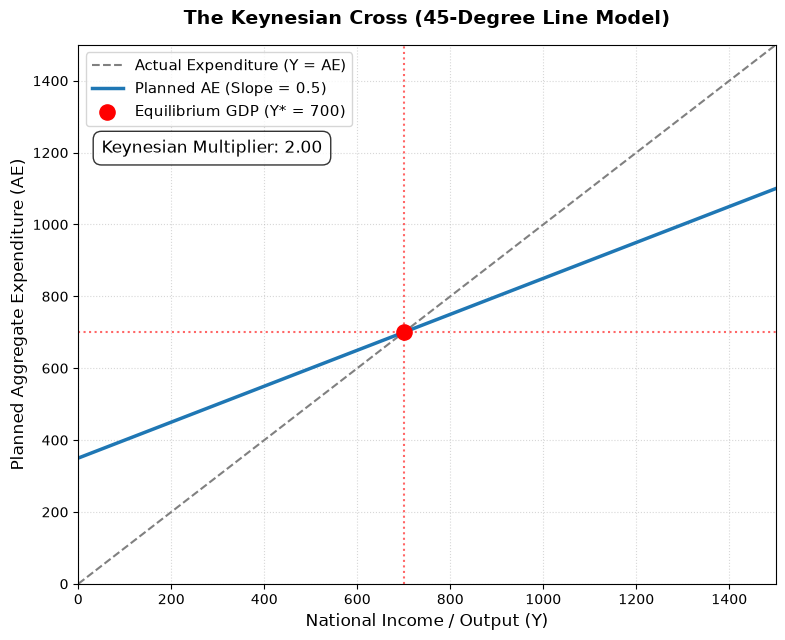

In [4]:

simulate_keynesian_cross(c1=0.5, G=150)
plt.show()
# 3. 마우스 조절 슬라이더 배치
# interact(
#     simulate_keynesian_cross,
#     c1=FloatSlider(min=0.5, max=0.9, step=0.05, value=0.75, description='한계소비(c1):'),
#     G=IntSlider(min=50, max=350, step=25, value=150, description='정부지출(G):')
# );
